In [18]:
!pip install groq -q

print("Libraries installed successfully")

Libraries installed successfully


In [19]:
import sqlite3

import pandas as pd

import os

from groq import Groq

import re
print("All libraries imported successfully")

All libraries imported successfully


In [20]:
import os
os.environ["GROQ_API_KEY"] = "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"
client = Groq(api_key=os.environ["GROQ_API_KEY"])
MODEL = "llma-3.1-8b-instant"
print("Groq client initialized successfully")
print(f"using model: {MODEL}")

Groq client initialized successfully
using model: llma-3.1-8b-instant


In [21]:
import io
data = pd.read_csv("/content/student_performance.csv")
display(data.head())

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [29]:
conn = sqlite3.connect("college.db")

data.to_sql("students", conn, if_exists="replace",index=False)

print("Database created: college_db")
print("Table 'studnets' created with 30 student records")

Test_df = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM students", conn)

print(f"\nVerification: {Test_df['total_rows'][0]} rows in database")

Database created: college_db
Table 'studnets' created with 30 student records

Verification: 30 rows in database


In [31]:
def get_schema(conn, table_name="students"):
    cursor = conn.cursor()

    cursor.execute(f"PRAGMA table_info({table_name})")
    columns = cursor.fetchall()

    schema_lines = [f"Table: {table_name}"]
    schema_lines.append("Columns:")

    for col in columns:
        schema_lines.append(f"  -{col[1]} ({col[2]})")

    cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
    sample_rows = cursor.fetchall()
    schema_lines.append("\nSample rows (first 3):")

    for row in sample_rows:
        schema_lines.append(f"  {row}")

    return "\n".join(schema_lines)
    schema = get_schema(conn)
    print(schema)

In [32]:
def get_schema(conn, table_name="students"):
    cursor = conn.cursor()

    cursor.execute(f"PRAGMA table_info({table_name})")
    columns = cursor.fetchall()

    schema_lines = [f"Table: {table_name}"]
    schema_lines.append("Columns:")

    for col in columns:
        schema_lines.append(f"  -{col[1]} ({col[2]})")

    cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
    sample_rows = cursor.fetchall()
    schema_lines.append("\nSample rows (first 3):")

    for row in sample_rows:
        schema_lines.append(f"  {row}")

    return "\n".join(schema_lines)
schema = get_schema(conn)
print(schema)

Table: students
Columns:
  -student_id (INTEGER)
  -name (TEXT)
  -age (INTEGER)
  -gender (TEXT)
  -department (TEXT)
  -semester (INTEGER)
  -math_score (INTEGER)
  -science_score (INTEGER)
  -english_score (INTEGER)
  -programming_score (INTEGER)
  -attendance_percentage (INTEGER)
  -city (TEXT)
  -admission_year (INTEGER)

Sample rows (first 3):
  (1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
  (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
  (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)


In [33]:
def generate_sql(user_question, schema_text, client, model):
  """
  Sends the user's question and database schema to the LLM to generate an SQL query.
  """

  system_prompt = f"""You are an expert SQL assistant.
  You are connected to a SQLite database with the following structure:
  {schema_text}


  RULES YOU MUST FOLLOW :
  1. Generate ONLY a valid SQLite SQL query.
  2. Do not include any explanation or text — only the SQL query.
  3. Do not use markdown code blocks. Return the raw SQL only.
  4. The table name is: students
  5. Only use column names that exist in the schema above.
  6. Use single quotes for string values in WHERE clauses (example: WHERE subject = 'Programming').
  7. If the user asks for top N, use ORDER BY marks DESC LIMIT N.
  """
  response =  client.chat.completions.create(
  model = model,
  messages =[
  {
      "role": "system", "content": system_prompt
  },
  {
      "role": "user", "content": user_question
  }
  ],
  temperature =0.0
  )
  sql_query = response.choices[0].message.content.strip()
  return sql_query

question = "show me all female students"

print(f" question :{question}")
print("\nGenerating SQL....")

MODEL = "llama-3.1-8b-instant" # Corrected model name
sql = generate_sql(question, schema, client, MODEL)
print(f"\nGenerated SQL : {sql}")

 question :show me all female students

Generating SQL....

Generated SQL : SELECT * FROM students WHERE gender = 'Female'


In [34]:
import re

def execute_sql(sql_query, conn):
    clean_sql = sql_query.strip()

    clean_sql = re.sub(r"```sql\s*", "", clean_sql, flags=re.IGNORECASE)
    clean_sql = re.sub(r"```", "", clean_sql)

    clean_sql = clean_sql.strip()
    try:
        result_df = pd.read_sql_query(clean_sql, conn)
        return result_df, None
    except Exception as e:
        return None, str(e)

print(f"Executing SQL: {sql}")
result, error = execute_sql(sql, conn)

if error:
    print(f"Error: {error}")
else:
    print(f"\nQuery returned {len(result)} rows:")
    print(result)

Executing SQL: SELECT * FROM students WHERE gender = 'Female'

Query returned 15 rows:
    student_id            name  age  gender        department  semester  \
0         1002     Priya Patel   20  Female  Computer Science         2   
1         1004     Sneha Reddy   20  Female        Mechanical         2   
2         1006     Meera Joshi   20  Female       Electronics         2   
3         1008     Divya Singh   19  Female  Computer Science         2   
4         1010      Ananya Das   19  Female  Computer Science         2   
5         1012     Pooja Gupta   19  Female             Civil         2   
6         1014   Kavya Nambiar   20  Female        Mechanical         2   
7         1016    Ritu Agarwal   20  Female       Electronics         2   
8         1018  Swati Kulkarni   19  Female  Computer Science         2   
9         1020    Nisha Kapoor   19  Female  Computer Science         2   
10        1022     Tanvi Mehta   19  Female  Computer Science         2   
11        102

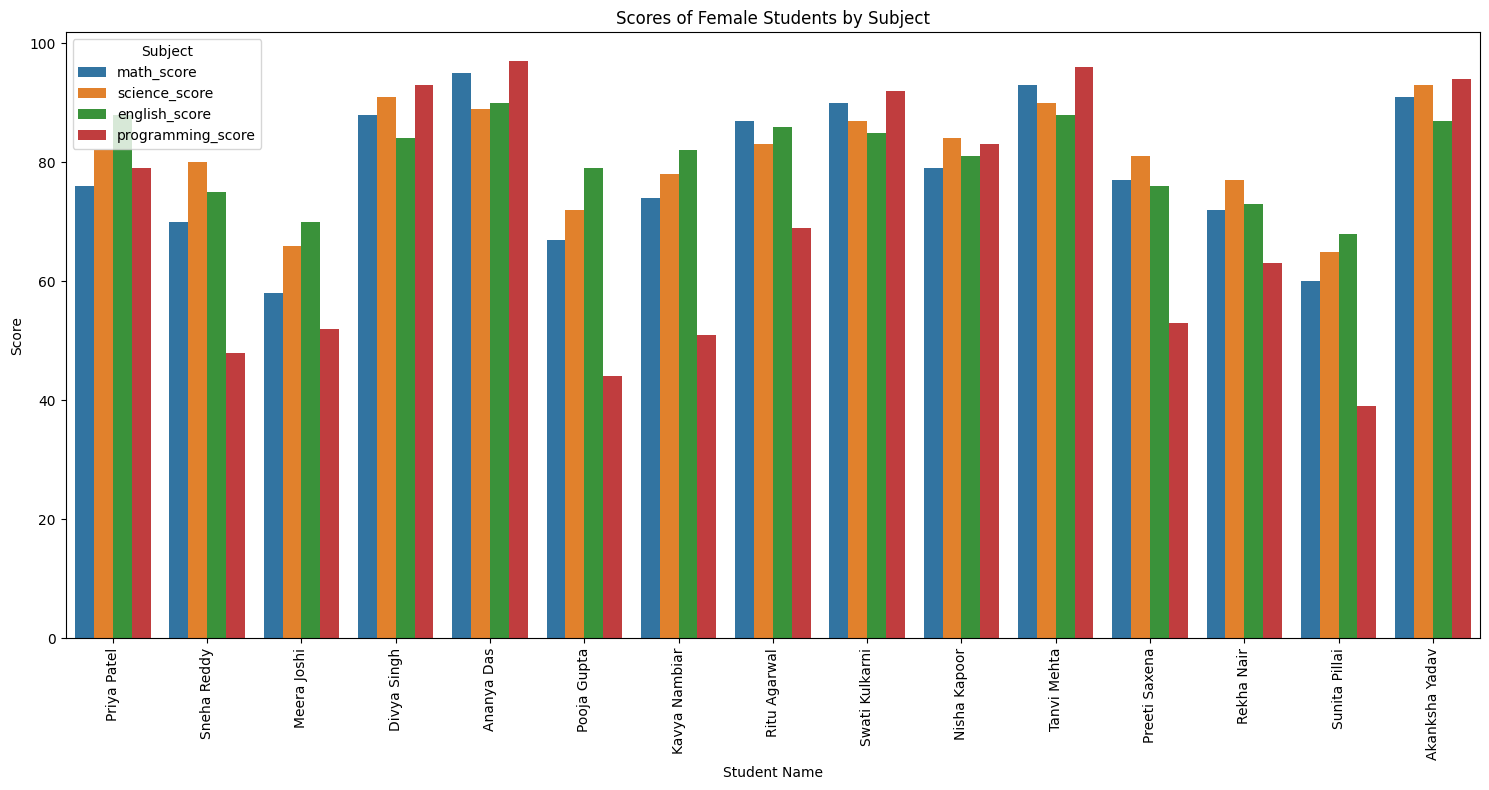

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
scores_df = result[['name', 'math_score', 'science_score', 'english_score', 'programming_score']]
scores_df_melted = scores_df.melt(id_vars='name', var_name='Subject', value_name='Score')

plt.figure(figsize=(15, 8))
sns.barplot(x='name', y='Score', hue='Subject', data=scores_df_melted)
plt.title('Scores of Female Students by Subject')
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.xticks(rotation=90)
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

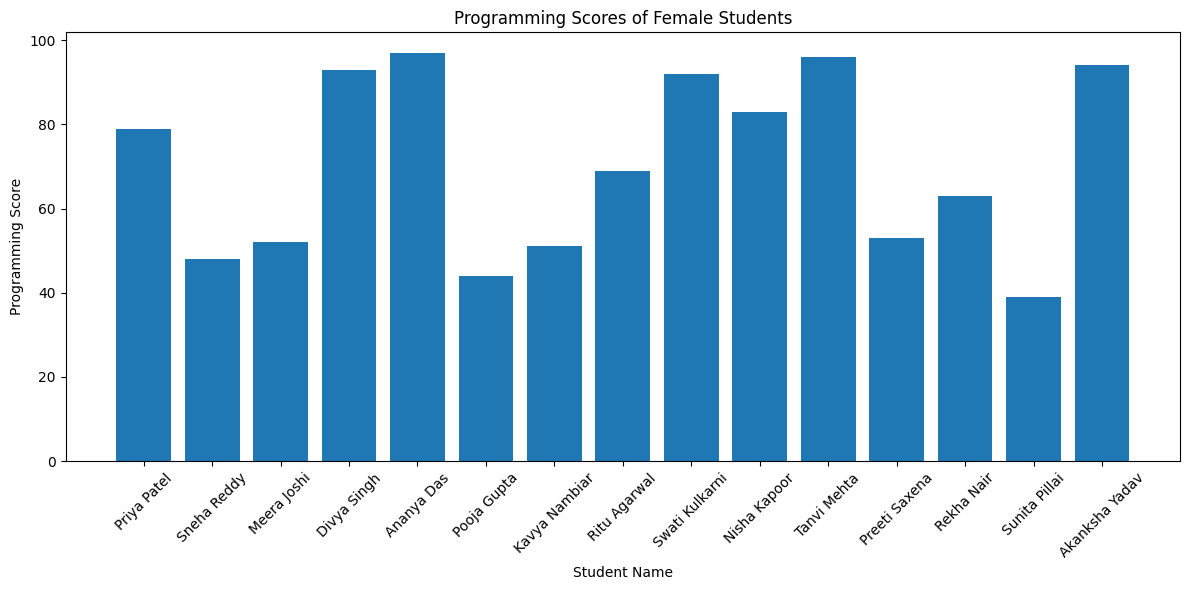

In [36]:
import matplotlib.pyplot as plt

# Assuming result contains the query output DataFrame

plt.figure(figsize=(12, 6))

plt.bar(result['name'], result['programming_score'])

plt.xlabel("Student Name")
plt.ylabel("Programming Score")
plt.title("Programming Scores of Female Students")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

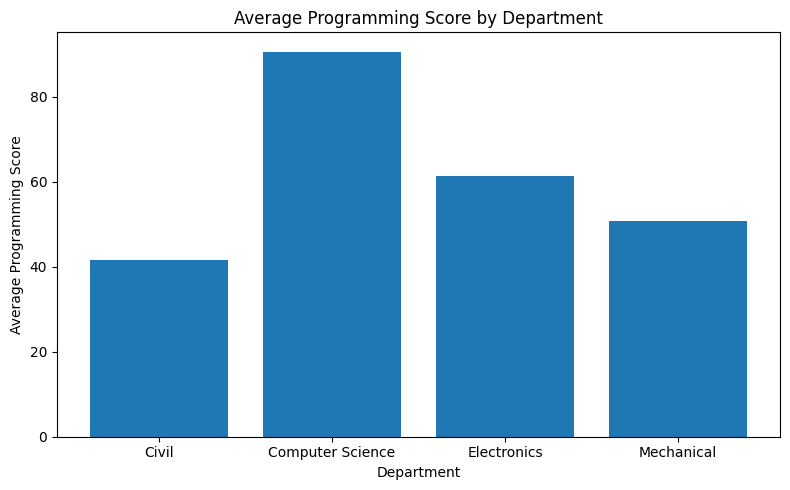

In [37]:
import matplotlib.pyplot as plt

dept_avg = result.groupby('department')['programming_score'].mean()

plt.figure(figsize=(8, 5))

plt.bar(dept_avg.index, dept_avg.values)

plt.xlabel("Department")
plt.ylabel("Average Programming Score")
plt.title("Average Programming Score by Department")

plt.tight_layout()
plt.show()

In [11]:
def text_to_sql_agent(user_question, conn, client, model, verbose=True):
 print(f" question :{user_question}")
 print("=" * 60)

 if verbose:
  print("\n[STEP 1] Reading database schema...")

  schema_text = get_schema(conn)

  if verbose:
    print("Schema loaded successfully")

    if verbose:
      print(f"Generating SQL : \n {generates_sql}")


    if verbose:
      print("\n[STEP 2] Generating SQL query with Groq LLM...")

    generate_sql_ = generate_sql(user_question, schema_text, client, model)

    if verbose:
      print("SQL query generated successfully")

      if verbose:
        print(f"Executing SQL on the database...")

      result, error = execute_sql(generate_sql_, conn)

      if error:
        print(f"SQL Execution Error: {error}")
      return None, generated_sql

      if verbose:
        print(f"\n[STEP 4] QUERY returned {len(result_df)} row()")
        print("\nRESULTS:")
        print("-" * 40)
        print(result_df.to_string(index=False))
        print("=" * 40)
        return result_df, generated_sql

        result, sql_used = text_to_sql_agent(
            conn, client, MODEL
        )